# References

- https://github.com/MyoHub/myosuite/blob/main/tutorials/9_Computed_muscle_control.ipynb

# Introduction

In this tutorial a target trajectory will be replicated by MyoElbow (2 dof 6 muscles) using **Computed Muscle Control**, given a sequence of joint angles, angular velocity, and angular acceleration 
, a sequence of muscle control u will be generated. Meanwhile, the muscle control of the arm26.osim model during the same motion were computed using OpenSim CMC for comparison.

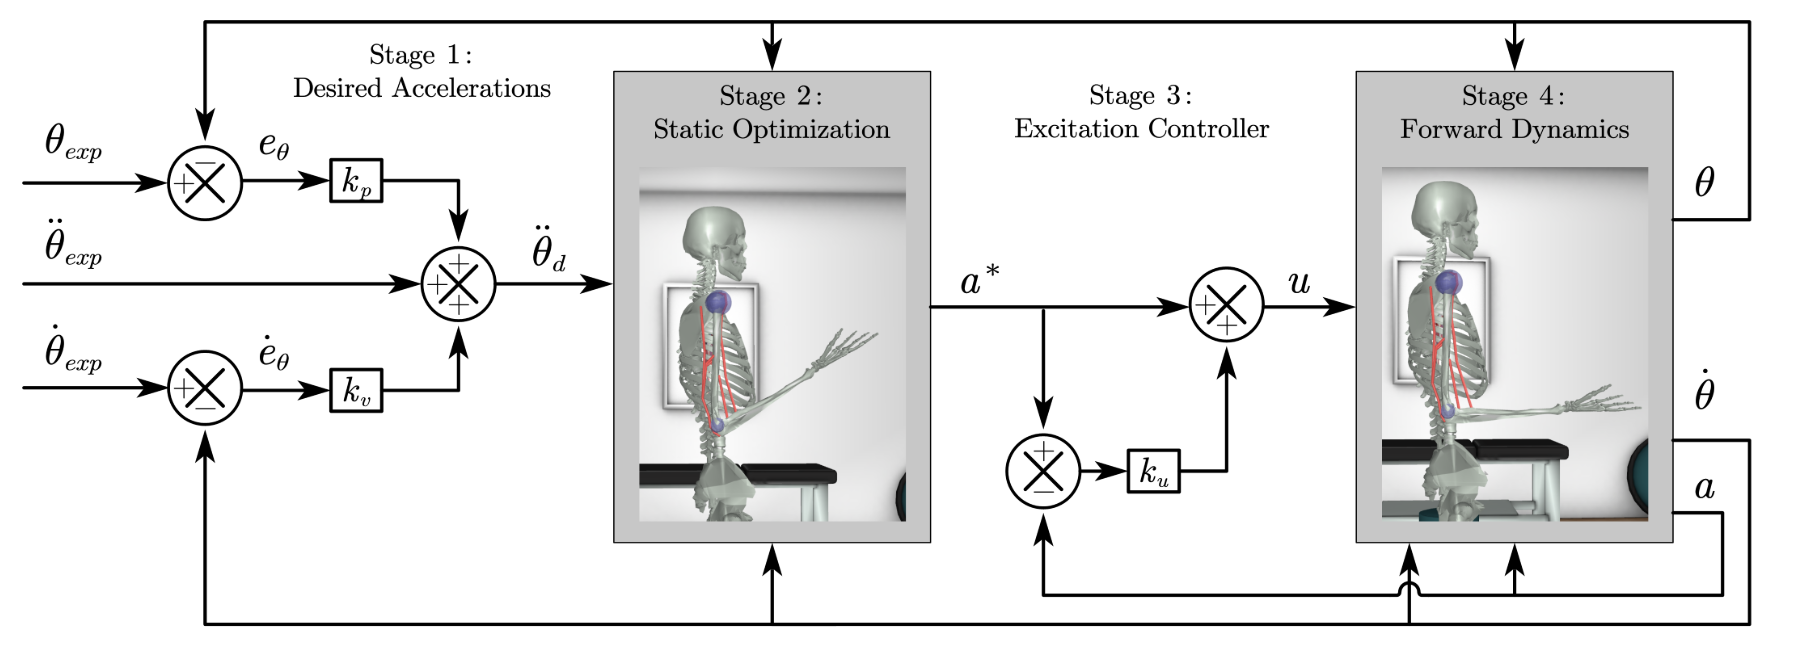

# Common Libraries

In [1]:
import os, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm
import mediapy as media
from copy import deepcopy
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import Video, display

if shutil.which('nvidia-smi') is not None:
    os.environ['MUJOCO_GL'] = 'egl'
import mujoco
from myosuite.simhive.myo_sim.test_sims import TestSims as loader

MyoSuite:> Registering Myo Envs


/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spe

# Functions

In [2]:
def StaticOpt(model: mujoco.MjModel,
              data: mujoco.MjData,
              qacc_d: np.ndarray,
              max_iter: int = 100):
    """
    Perform static optimization to find muscle activations that satisfy 
    the desired acceleration while minimizing the sum of squared activations.

    :param model: MuJoCo model object
    :param data: MuJoCo data object
    :param qacc_d: Desired acceleration vector ex) np.array([0, 0.2])
    :param max_iter: Maximum number of iterations for the optimizer
    
    :return: Optimization result object
    """
    initial_state = np.concatenate([data.qpos, data.qvel])
    initial_act = data.act.copy()
    n_actuators = model.nu

    def loss_fn(act):
        return 0.5 * np.sum(act**2)

    def acceleration_constraint(act):
        mujoco.mj_resetData(model, data)
        data.qpos[:] = initial_state[:model.nq]
        data.qvel[:] = initial_state[model.nq:]
        data.act[:] = act
        mujoco.mj_step(model, data)
        return data.qacc - qacc_d

    constraints = {
        'type': 'eq',
        'fun': acceleration_constraint,
        'tol': 1e-6
    }

    bounds = [(0, 1.0) for _ in range(n_actuators)]
    result = minimize(loss_fn,
                      x0 = initial_act,
                      method = "SLSQP",
                      bounds = bounds,
                      constraints = constraints,
                      options = {'maxiter': max_iter, 'disp': False})
    return result

# Params

In [3]:
myosuite_tuturial_dir_path = "/home/seojin/biomechanics_tools/myosuite/tutorials"
data_dir_path = os.path.join(myosuite_tuturial_dir_path, "data")
trajectory_path = os.path.join(data_dir_path, "9_joint_trajectory.csv")
opensim_cmc_path = os.path.join(data_dir_path, "9_Opensim_cmc.csv")

# Load data

In [4]:
traj = pd.read_csv(trajectory_path)
times = traj["time"]
n_exp_times = times.shape[0]

# Initialize models

In [5]:
model0 = loader.get_sim(None, 'elbow/myoelbow_2dof6muscles.xml')  # for static optimization
n_joints, n_controls = model0.nv, model0.nu
joint_names = [model0.joint(i).name for i in range(model0.njnt)]
muscle_names = [model0.actuator(i).name for i in range(model0.nu)]

model1 = loader.get_sim(None, 'elbow/myoelbow_2dof6muscles.xml')  # for forward dynamics

# Compute muscle activation signal

## First stage: calculate desired joint acceleration

$$ \ddot{\theta}_{d} = \ddot{\theta}_{exp} + k_{v}(\dot{\theta}_{exp} - \dot{\theta}) + k_{p}(\theta_{exp} - \theta)$$

$\ddot{\theta}_d$ is angular desired acceleration.

$\theta_{exp}$, $\dot{\theta}_{exp}$, $\ddot{\theta}_{exp}$ are the reference joint angle, angular velocity, and angular acceleration, respectively. 

$\theta$, $\dot{\theta}$ are the joint angle and angular velocity of the model at the current time step, respectively.

$k_v$, $k_p$ are the velocity gain and position gain, respectively.

To make the errors converge to zero in a critically damped manner, $k_v = 2\sqrt{k_p}$

Here we set $k_p = 100$ and $k_v = 20$

## Second stage: static optimization

For the static optimization problem, the performacne criterion was chosen to be the sum of squared muscle activations:

$$ min \sum_{m=1}^{N}(a_m^*)^2$$

$$ s.t. \ddot{\theta}^{*} = \ddot{\theta}_d $$

$$ 0 \le a_m \le 1 $$

## Third Stage (Muscle excitations controller)

u is the muscle activation, $a^*$ is the optimal muscle activations computed in stage 2, and $a$ is the current muscle activations in forwrad dynamics simulation, $k_u$ is the feedback gain. Here we set $k_u$ = 1.

$$\begin{aligned}
u & = a^{*} + k_u(a^{*} - a) \\
u & = clip(0, 1, u)
\end{aligned}$$

In [6]:
kp = 100
kv = 2*np.sqrt(kp)
ku = 1

myosuite_all_qpos_df = pd.DataFrame(np.zeros((n_exp_times, n_joints)), columns = joint_names)
myosuite_all_ctrl_df = pd.DataFrame(np.zeros((n_exp_times, n_controls)), columns = muscle_names)
data1 = mujoco.MjData(model1)

for time_i in tqdm(range(n_exp_times)):
    # Get experimental datas
    exp_pos = traj.loc[time_i, ["angle1", "angle2"]].values
    exp_vel = traj.loc[time_i, ["velocity1", "velocity2"]].values
    exp_acc = traj.loc[time_i, ["acceleration1", "acceleration2"]].values
    data0 = deepcopy(data1)

    # First stage: Calculate desired angular acceleration
    q = data1.qpos
    qvel = data1.qvel
    qacc_d = exp_acc + kv * (exp_vel - qvel) + kp * (exp_pos - q)
    
    # Second stage: Static optimization
    so_result = StaticOpt(model0, data0, qacc_d, max_iter=100)
    opt_a = so_result.x

    # Third stage: Calculate control signal
    u = opt_a + ku * (opt_a - data1.act)
    u = np.clip(u, 0, 1.0)
    data1.ctrl = u

    # Fourth stage: Foward dynamics
    mujoco.mj_step(model1, data1)
    myosuite_all_qpos_df.loc[time_i, :] = data1.qpos
    myosuite_all_ctrl_df.loc[time_i, :] = u

100%|██████████| 501/501 [00:20<00:00, 24.77it/s]


# Validation

In [19]:
opensim_cmc_df = pd.read_csv(opensim_cmc_path, skiprows=6)

## Joint angle Comparison (MyoSuite CMC vs OpenSim CMC)

In [20]:
myosuite_simulation_times = np.arange(myosuite_all_qpos_df.shape[0]) * (times[1] - times[0])
opensim_simulation_times = np.arange(opensim_cmc_df.shape[0]) * 0.002

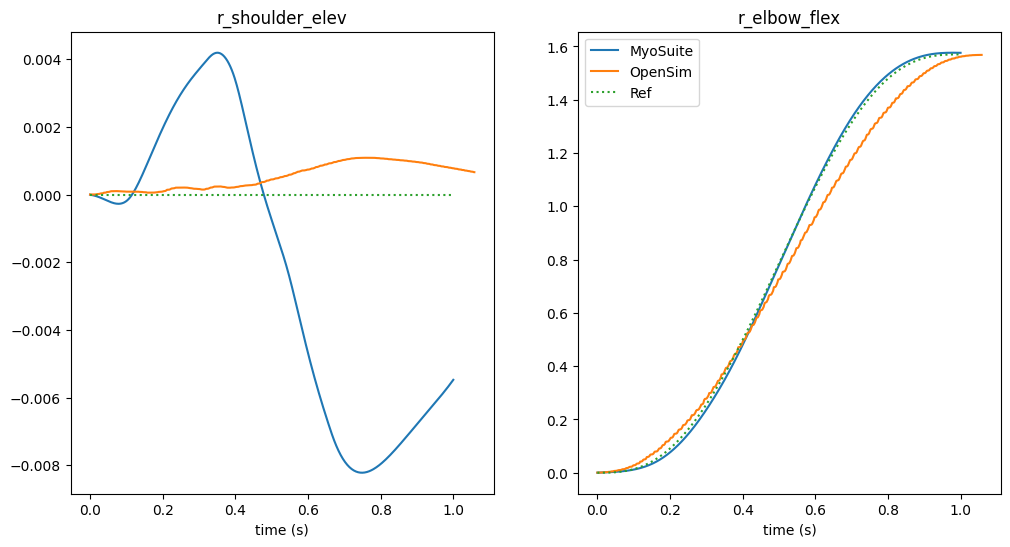

In [21]:
fig, axes = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.set_figheight(6)
for joint_i in range(n_joints):
    joint_name = joint_names[joint_i]
    axis = axes[joint_i]
    
    axis.plot(myosuite_simulation_times,
              myosuite_all_qpos_df[joint_name],
              label=f"MyoSuite")
    axis.plot(opensim_simulation_times,
              opensim_cmc_df[joint_name],
              label=f"OpenSim")
    axis.plot(times,
              traj[f"angle{joint_i + 1}"],
              ":",
              label=f"Ref")

    axis.set_xlabel("time (s)")
    axis.set_title(joint_names[joint_i])
plt.legend()

## Muscle activation signal comparison (MyoSuite CMC vs OpenSim CMC)

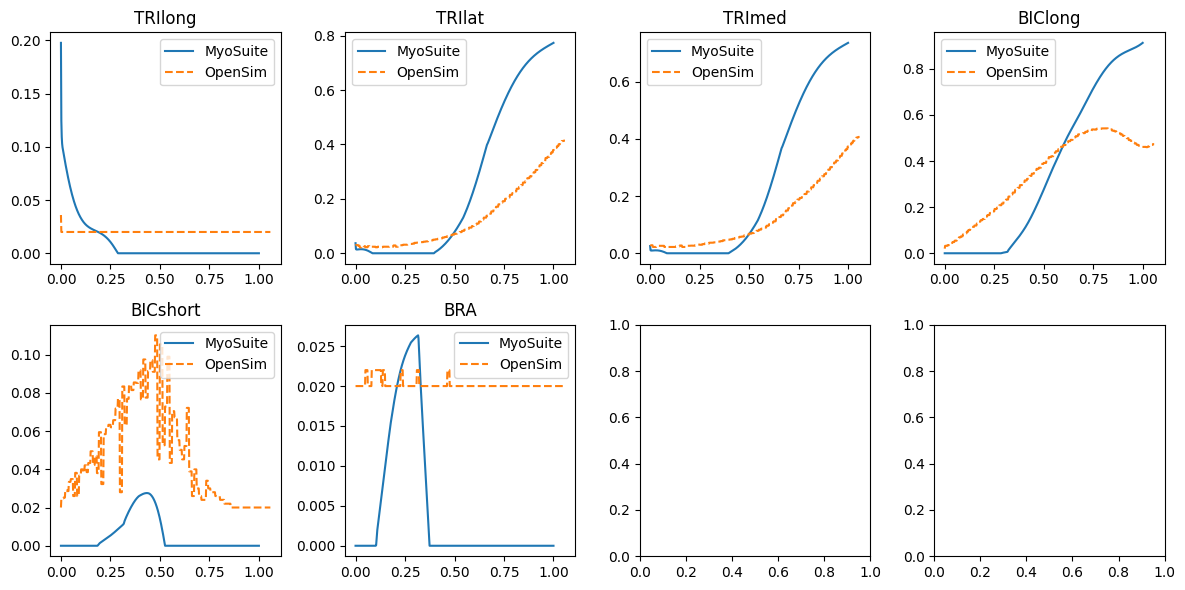

In [22]:
fig, axes = plt.subplots(2, 4)
axes = axes.flatten()
fig.set_figwidth(12)
fig.set_figheight(6)

for control_i in range(n_controls):
    muscle_name = muscle_names[control_i]
    
    ax = axes[control_i]
    ax.plot(myosuite_simulation_times, myosuite_all_ctrl_df[muscle_name], label = "MyoSuite")
    ax.plot(opensim_simulation_times, opensim_cmc_df[muscle_name], "--", label = "OpenSim")
    ax.set_title(f"{muscle_name}")
    ax.legend()
plt.tight_layout()
plt.show()

# Video generalization

In [23]:
# Model
model_ref = loader.get_sim(None, 'elbow/myoelbow_2dof6muscles.xml')
data_ref = mujoco.MjData(model_ref) # data for reference trajectory
model_test = loader.get_sim(None, 'elbow/myoelbow_2dof6muscles.xml')
data_test = mujoco.MjData(model_test) # test data for achieved trajectory

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.distance =  1.1070990185160428
camera.elevation = -10.232281643227267
camera.lookat = np.array([-0.1130067696435806, 0.0815790401272094, 1.0655519045043413])

# Render
options_ref = mujoco.MjvOption()
options_ref.flags[:] = 0
options_ref.flags[[1, 22]] = 1
options_ref.geomgroup[2:] = 0

options_test = mujoco.MjvOption()
options_test.flags[:] = 0
options_test.flags[[1, 4, 22]] = 1
options_test.geomgroup[:] = 1

renderer_ref = mujoco.Renderer(model_ref, width=480, height=480)
renderer_ref.scene.flags[:] = 0

renderer_test = mujoco.Renderer(model_test, width=480, height=480)
renderer_test.scene.flags[:] = 0

# Frame
frames = []
for time_i in tqdm(range(n_exp_times)):
    data_ref.qpos = [traj.loc[time_i, "angle1"], traj.loc[time_i, "angle2"]]
    mujoco.mj_step1(model_ref, data_ref)

    data_test.ctrl = myosuite_all_ctrl_df.loc[time_i].values
    mujoco.mj_step(model_test, data_test)
    
    if not time_i % round(0.3/(model_test.opt.timestep*25)):
        renderer_ref.update_scene(data_ref, camera=camera, scene_option=options_ref)
        frame_ref = renderer_ref.render()
        renderer_test.update_scene(data_test, camera=camera, scene_option=options_test)
        frame_test = renderer_test.render()
        frame_merged = np.append(frame_ref, frame_test, axis=1)
        frames.append(frame_merged)

100%|██████████| 501/501 [00:00<00:00, 2184.32it/s]


In [24]:
media.show_video(frames, fps=30)

This browser does not support the video tag.
